In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms as T






In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()

        # Encoder
        self.encoder1 = self.conv_block(in_channels, 64)
        self.encoder2 = self.conv_block(64, 128)
        self.encoder3 = self.conv_block(128, 256)
        self.encoder4 = self.conv_block(256, 512)

        # Bottleneck
        self.bottleneck = self.conv_block(512, 1024)

        # Decoder
        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.decoder4 = self.conv_block(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.decoder3 = self.conv_block(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.decoder2 = self.conv_block(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.decoder1 = self.conv_block(128, 64)

        # Final output layer
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

        # MaxPool layer
        self.maxpool = nn.MaxPool2d(2, 2)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.maxpool(e1))
        e3 = self.encoder3(self.maxpool(e2))
        e4 = self.encoder4(self.maxpool(e3))

        # Bottleneck
        b = self.bottleneck(self.maxpool(e4))

        # Decoder with skip connections
        d4 = self.upconv4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.decoder4(d4)

        d3 = self.upconv3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.decoder3(d3)

        d2 = self.upconv2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.decoder2(d2)

        d1 = self.upconv1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.decoder1(d1)

        # Final convolution
        out = self.final_conv(d1)
        return out

In [ ]:
# Dataset Preparation (Pascal VOC 2012)
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])


target_transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor(),
])

# Load Pascal VOC segmentation dataset
train_dataset = datasets.VOCSegmentation(root='./data', year='2012', image_set='train',
                                        download=True, transform=transform,
                                        target_transform=target_transform)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

test_dataset = datasets.VOCSegmentation(root='./data', year='2012', image_set='val',
                                       download=True, transform=transform,
                                       target_transform=target_transform)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

100%|██████████| 2.00G/2.00G [01:12<00:00, 27.5MB/s]


Image Shape: torch.Size([4, 3, 256, 256]), Target Shape: torch.Size([4, 1, 256, 256])


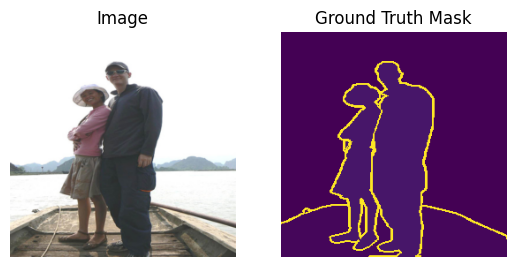

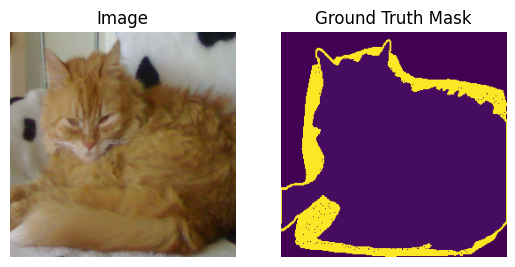

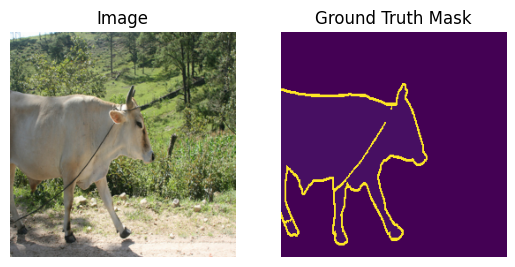

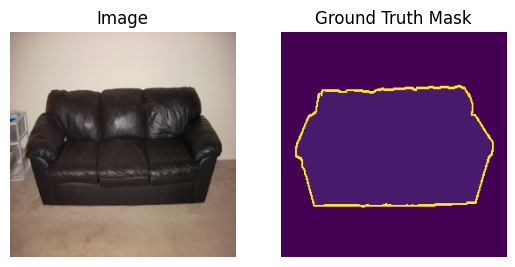

In [ ]:

# Randomly display a few images from the training set
def show_sample_images():
    data_iter = iter(train_loader)
    #images, targets = data_iter.next()
    images, targets = next(data_iter)
    print(f"Image Shape: {images.shape}, Target Shape: {targets.shape}")

    # Show images and their ground truth masks
    for i in range(len(images)):
        plt.subplot(1, 2, 1)
        plt.imshow(images[i].permute(1, 2, 0))  # Change from (C, H, W) to (H, W, C)
        plt.title('Image')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(targets[i].permute(1, 2, 0))  # Change from (C, H, W) to (H, W, C)
        plt.title('Ground Truth Mask')
        plt.axis('off')

        plt.show()

show_sample_images()

In [ ]:
# Model, Loss, and Optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=3, out_channels=21).to(device)  # Pascal VOC has 21 classes
criterion = nn.CrossEntropyLoss()  # CrossEntropyLoss for segmentation
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training the model
num_epochs = 20
train_loss_history = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, targets in train_loader:
        images, targets = images.to(device), targets.to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, targets.squeeze(1).long())  # Squeeze target to remove the channel dimension
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_loss_history.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

# Plotting the loss graph
plt.plot(range(1, num_epochs+1), train_loss_history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [ ]:
# Evaluate on a test image
model.eval()
with torch.no_grad():
    test_image, test_mask = test_dataset[0]  # Taking one image for evaluation
    test_image = test_image.unsqueeze(0).to(device)
    test_mask = test_mask.unsqueeze(0).to(device)

    # Model Prediction
    predicted_mask = model(test_image)

    # Get the predicted class by taking the argmax
    predicted_mask = torch.argmax(predicted_mask, dim=1).squeeze().cpu().numpy()
    test_mask = test_mask.squeeze().cpu().numpy()

    # Plotting the results
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 3, 1)
    plt.title('Test Image')
    plt.imshow(test_image.squeeze().permute(1, 2, 0).cpu())  # Convert to HWC format
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title('Ground Truth Mask')
    plt.imshow(test_mask)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title('Predicted Mask')
    plt.imshow(predicted_mask)
    plt.axis('off')

    plt.show()
